Image shape: (200, 197), min=2600, max=6357560


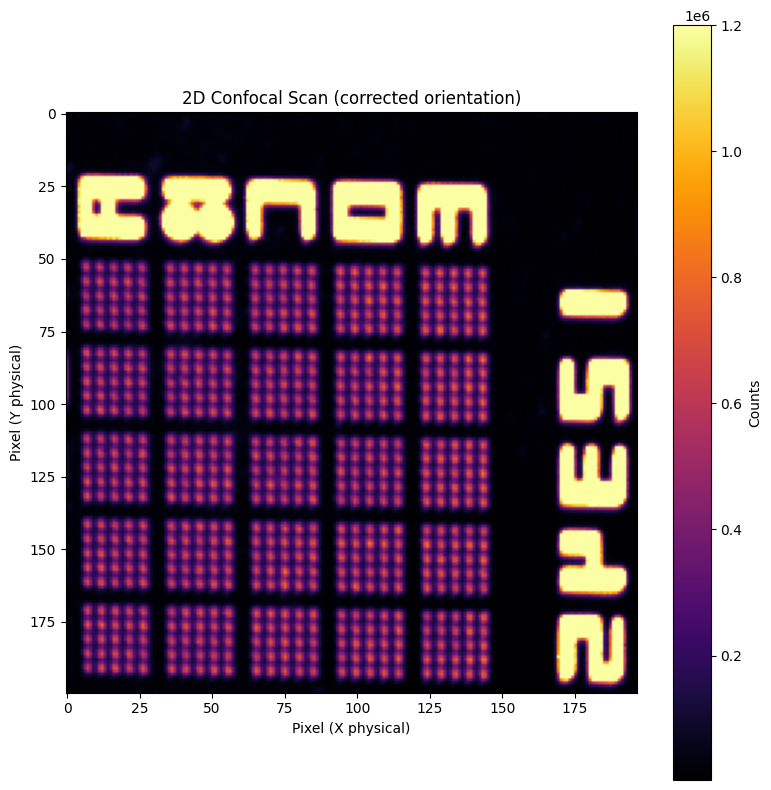

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.ndimage import uniform_filter

DATA_FILE = r'C:\Users\SPUD1\Documents\experiment_workspace\qudi_data\2026\07\2026-07-07\scanning_data_logic\20260707-1222-13_2D-scan_with_xy_axes_from_channel_APD1.txt'

rows = []
with open(DATA_FILE, 'r') as f:
    for line in f:
        if line.startswith('#') or line.strip() == '':
            continue
        rows.append([float(v) for v in line.strip().split('\t')])

img_raw = np.array(rows)  # shape (200, 200), as scanned

# Scan stores data rotated 90° CW vs physical orientation; correct it.
img = np.rot90(img_raw, k=1)   # k=1 → 90° CCW rotation
img = img[:, 3:]                # crop 3-px strip at left edge (adjacent-matrix markers)

print(f"Image shape: {img.shape}, min={img.min():.0f}, max={img.max():.0f}")

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(img, origin='upper', cmap='inferno',
               vmax=1.2e6)
plt.colorbar(im, ax=ax, label='Counts')
ax.set_xlabel('Pixel (X physical)')
ax.set_ylabel('Pixel (Y physical)')
ax.set_title('2D Confocal Scan (corrected orientation)')
plt.tight_layout()
plt.show()

Column centres (A-E): [ 14  45  78 104 131]
Row    centres (1-5): [ 65  95 128 158 182]


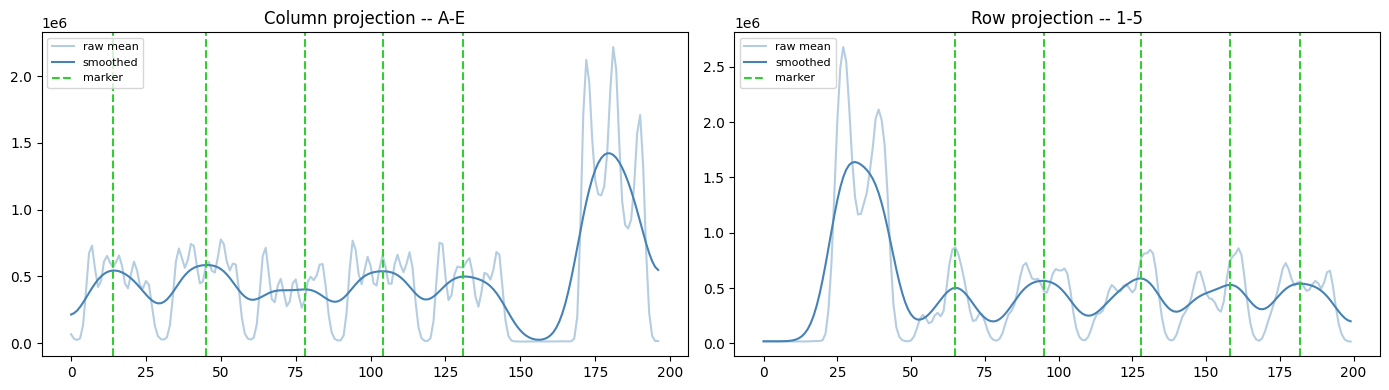

In [10]:
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

def find_marker_centers(proj, n_markers=5, smooth_sigma=5, min_distance=20):
    """
    Smooth the projection, find all peaks, sort tallest-first.
    The tallest peak is contamination from the orthogonal markers; discard it.
    The next n_markers peaks (by height) are the real alignment markers.
    """
    smooth = gaussian_filter1d(proj.astype(float), sigma=smooth_sigma)
    peaks, props = find_peaks(smooth, distance=min_distance, prominence=0)
    # Sort peaks by height descending; drop the tallest (contamination)
    peaks_sorted = peaks[np.argsort(smooth[peaks])[::-1]]
    marker_peaks = np.sort(peaks_sorted[1 : n_markers + 1])  # re-sort by position
    return marker_peaks, smooth

col_proj = img.mean(axis=0)
row_proj = img.mean(axis=1)

col_centers, col_smooth = find_marker_centers(col_proj)
row_centers, row_smooth = find_marker_centers(row_proj)
print(f"Column centres (A-E): {col_centers}")
print(f"Row    centres (1-5): {row_centers}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, proj, smooth, centers, title in [
    (axes[0], col_proj, col_smooth, col_centers, 'Column projection -- A-E'),
    (axes[1], row_proj, row_smooth, row_centers, 'Row projection -- 1-5'),
]:
    ax.plot(proj, color='steelblue', alpha=0.4, label='raw mean')
    ax.plot(smooth, color='steelblue', label='smoothed')
    for i, c in enumerate(centers):
        ax.axvline(c, color='limegreen', ls='--', lw=1.5,
                   label='marker' if i == 0 else '')
    ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


Array column centres (px): [ 14  45  78 104 131]
Array row    centres (px): [ 65  95 128 158 182]
→ 5×5 = 25 arrays


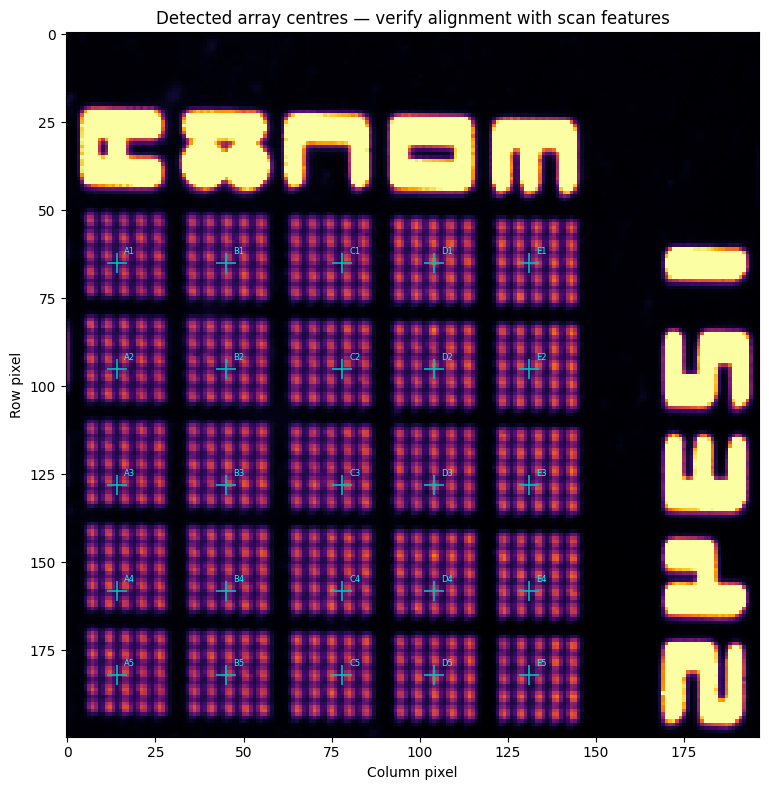

In [11]:
# The letter markers define the column X-positions of the 5 array columns (A–E).
# The number markers define the row Y-positions of the 5 array rows (1–5).
# The 25 array centres are at every (col, row) combination.

array_col_centres = col_centers   # pixel X positions of columns A, B, C, D, E
array_row_centres = row_centers   # pixel Y positions of rows 1, 2, 3, 4, 5

print(f"Array column centres (px): {array_col_centres}")
print(f"Array row    centres (px): {array_row_centres}")
print(f"→ {len(array_col_centres)}×{len(array_row_centres)} = "
      f"{len(array_col_centres)*len(array_row_centres)} arrays")

# Overlay on scan image to verify
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img, origin='upper', cmap='inferno', vmax=1.2e6)
for ri, rc in enumerate(array_row_centres):
    for ci, cc in enumerate(array_col_centres):
        ax.plot(cc, rc, 'c+', markersize=14, markeredgewidth=1.2)
        ax.text(cc + 2, rc - 2, f'{list("ABCDE")[ci]}{ri+1}',
                color='cyan', fontsize=6, va='bottom')
ax.set_title('Detected array centres — verify alignment with scan features')
ax.set_xlabel('Column pixel'); ax.set_ylabel('Row pixel')
plt.tight_layout(); plt.show()


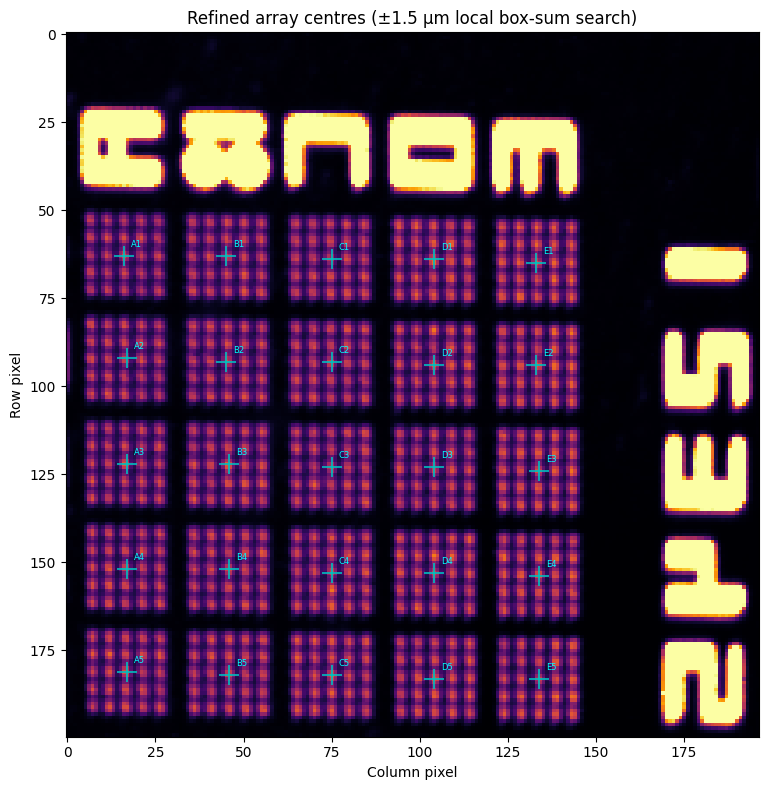

 Array   Δrow (px)   Δrow (µm)   Δcol (px)   Δcol (µm)
    A1          -2        -0.4          +2        +0.4
    B1          -2        -0.4          +0        +0.0
    C1          -1        -0.2          -3        -0.6
    D1          -1        -0.2          +0        +0.0
    E1          +0        +0.0          +2        +0.4
    A2          -3        -0.6          +3        +0.6
    B2          -2        -0.4          +0        +0.0
    C2          -2        -0.4          -3        -0.6
    D2          -1        -0.2          +0        +0.0
    E2          -1        -0.2          +2        +0.4
    A3          -6        -1.2          +3        +0.6
    B3          -6        -1.2          +1        +0.2
    C3          -5        -1.0          -3        -0.6
    D3          -5        -1.0          +0        +0.0
    E3          -4        -0.8          +3        +0.6
    A4          -6        -1.2          +3        +0.6
    B4          -6        -1.2          +1        +0.2
    C4    

In [12]:
# ── Refine array centres: local box-sum search ───────────────────────────────
# Sample rotation couples X and Y, so the projection-derived centres have
# independent X and Y errors.  For each array, search ±1.5 µm (= ±8 px) in
# both dimensions for the position that maximises the total counts in the
# 25×25 px (5 µm × 5 µm) window covering the full 5×5 spot grid.

ARRAY_WIN   = 25   # 5 µm / (0.2 µm/px)
SEARCH_HALF =  8   # 1.5 µm / (0.2 µm/px) rounded up

# Precompute 2D sliding box sum via uniform_filter (gives mean → scale to sum)
box_sum = uniform_filter(img.astype(float), size=ARRAY_WIN) * ARRAY_WIN ** 2

array_centers = {}   # (ri, ci) -> (row_px, col_px)

for ri, rc in enumerate(array_row_centres):
    for ci, cc in enumerate(array_col_centres):
        r0 = max(0, rc - SEARCH_HALF);  r1 = min(img.shape[0], rc + SEARCH_HALF + 1)
        c0 = max(0, cc - SEARCH_HALF);  c1 = min(img.shape[1], cc + SEARCH_HALF + 1)
        local = box_sum[r0:r1, c0:c1]
        dr, dc = np.unravel_index(np.argmax(local), local.shape)
        array_centers[(ri, ci)] = (r0 + dr, c0 + dc)

# Overlay refined centres and print offsets
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img, origin='upper', cmap='inferno', vmax=1.2e6)
for (ri, ci), (rc, cc) in array_centers.items():
    ax.plot(cc, rc, 'c+', markersize=14, markeredgewidth=1.2)
    ax.text(cc + 2, rc - 2, f'{list("ABCDE")[ci]}{ri+1}',
            color='cyan', fontsize=6, va='bottom')
ax.set_title('Refined array centres (±1.5 µm local box-sum search)')
ax.set_xlabel('Column pixel'); ax.set_ylabel('Row pixel')
plt.tight_layout(); plt.show()

print(f"{'Array':>6}  {'Δrow (px)':>10}  {'Δrow (µm)':>10}  {'Δcol (px)':>10}  {'Δcol (µm)':>10}")
for ri in range(5):
    for ci in range(5):
        nr, nc = array_centers[(ri, ci)]
        dr = nr - array_row_centres[ri]
        dc = nc - array_col_centres[ci]
        label = f'{list("ABCDE")[ci]}{ri+1}'
        print(f"{label:>6}  {dr:>+10d}  {dr*0.2:>+10.1f}  {dc:>+10d}  {dc*0.2:>+10.1f}")


In [13]:
# ── Per-spot counts: 4x4 window at brightest pixel ──────────────────────────
PITCH_PX         =  5   # 1 um / 0.2 um per pixel
HALF_GRID        =  2   # spots at offsets -2,-1,0,+1,+2 * PITCH_PX from centre
WIN              =  2   # 4x4 window half-width (indices [r-2:r+2, c-2:c+2])
SEARCH_HALF_SPOT =  3   # +-0.6 um search radius per spot

spot_offsets = np.arange(-HALF_GRID, HALF_GRID + 1) * PITCH_PX  # [-10,-5,0,5,10]

results = {}   # (ri, ci) -> dict

for ri in range(len(array_row_centres)):
    for ci in range(len(array_col_centres)):
        rc, cc = array_centers[(ri, ci)]   # refined centre for this array
        spot_counts = []
        spot_pos    = []
        for dy in spot_offsets:
            for dx in spot_offsets:
                nom_r = rc + dy
                nom_c = cc + dx
                r0 = max(0, nom_r - SEARCH_HALF_SPOT)
                r1 = min(img.shape[0], nom_r + SEARCH_HALF_SPOT + 1)
                c0 = max(0, nom_c - SEARCH_HALF_SPOT)
                c1 = min(img.shape[1], nom_c + SEARCH_HALF_SPOT + 1)
                patch = img[r0:r1, c0:c1]
                pr, pc = np.unravel_index(np.argmax(patch), patch.shape)
                pr += r0;  pc += c0
                wr0 = max(0, pr - WIN);  wr1 = min(img.shape[0], pr + WIN)
                wc0 = max(0, pc - WIN);  wc1 = min(img.shape[1], pc + WIN)
                spot_counts.append(img[wr0:wr1, wc0:wc1].sum())
                spot_pos.append((pr, pc))

        counts = np.array(spot_counts)
        results[(ri, ci)] = {
            "counts"   : counts,
            "mean"     : counts.mean(),
            "std"      : counts.std(),
            "cv"       : counts.std() / counts.mean(),
            "positions": spot_pos,
        }

print("Array  |  mean counts  |   std dev   |  CV (%)")
print("-" * 50)
for (ri, ci), v in sorted(results.items()):
    label = f'{chr(65+ci)}{ri+1}'
    print(f"  {label:<4} |  {v['mean']:10.0f}  |  {v['std']:9.0f}  |  {100*v['cv']:.1f}%")


Array  |  mean counts  |   std dev   |  CV (%)
--------------------------------------------------
  A1   |     5754123  |     480174  |  8.3%
  B1   |     6177285  |     454523  |  7.4%
  C1   |     6318301  |     361605  |  5.7%
  D1   |     6839454  |     448971  |  6.6%
  E1   |     6774438  |     414040  |  6.1%
  A2   |     6075947  |     286215  |  4.7%
  B2   |     6270358  |     271376  |  4.3%
  C2   |     6217382  |     350908  |  5.6%
  D2   |     6520982  |     414183  |  6.4%
  E2   |     6607054  |     529701  |  8.0%
  A3   |     6043658  |     359727  |  6.0%
  B3   |     6382512  |     348430  |  5.5%
  C3   |     6278458  |     490126  |  7.8%
  D3   |     6127931  |     329991  |  5.4%
  E3   |     6827902  |     372433  |  5.5%
  A4   |     6171971  |     358798  |  5.8%
  B4   |     6359123  |     314856  |  5.0%
  C4   |     6595597  |     521894  |  7.9%
  D4   |     6358882  |     433613  |  6.8%
  E4   |     6603824  |     575828  |  8.7%
  A5   |     6125298  

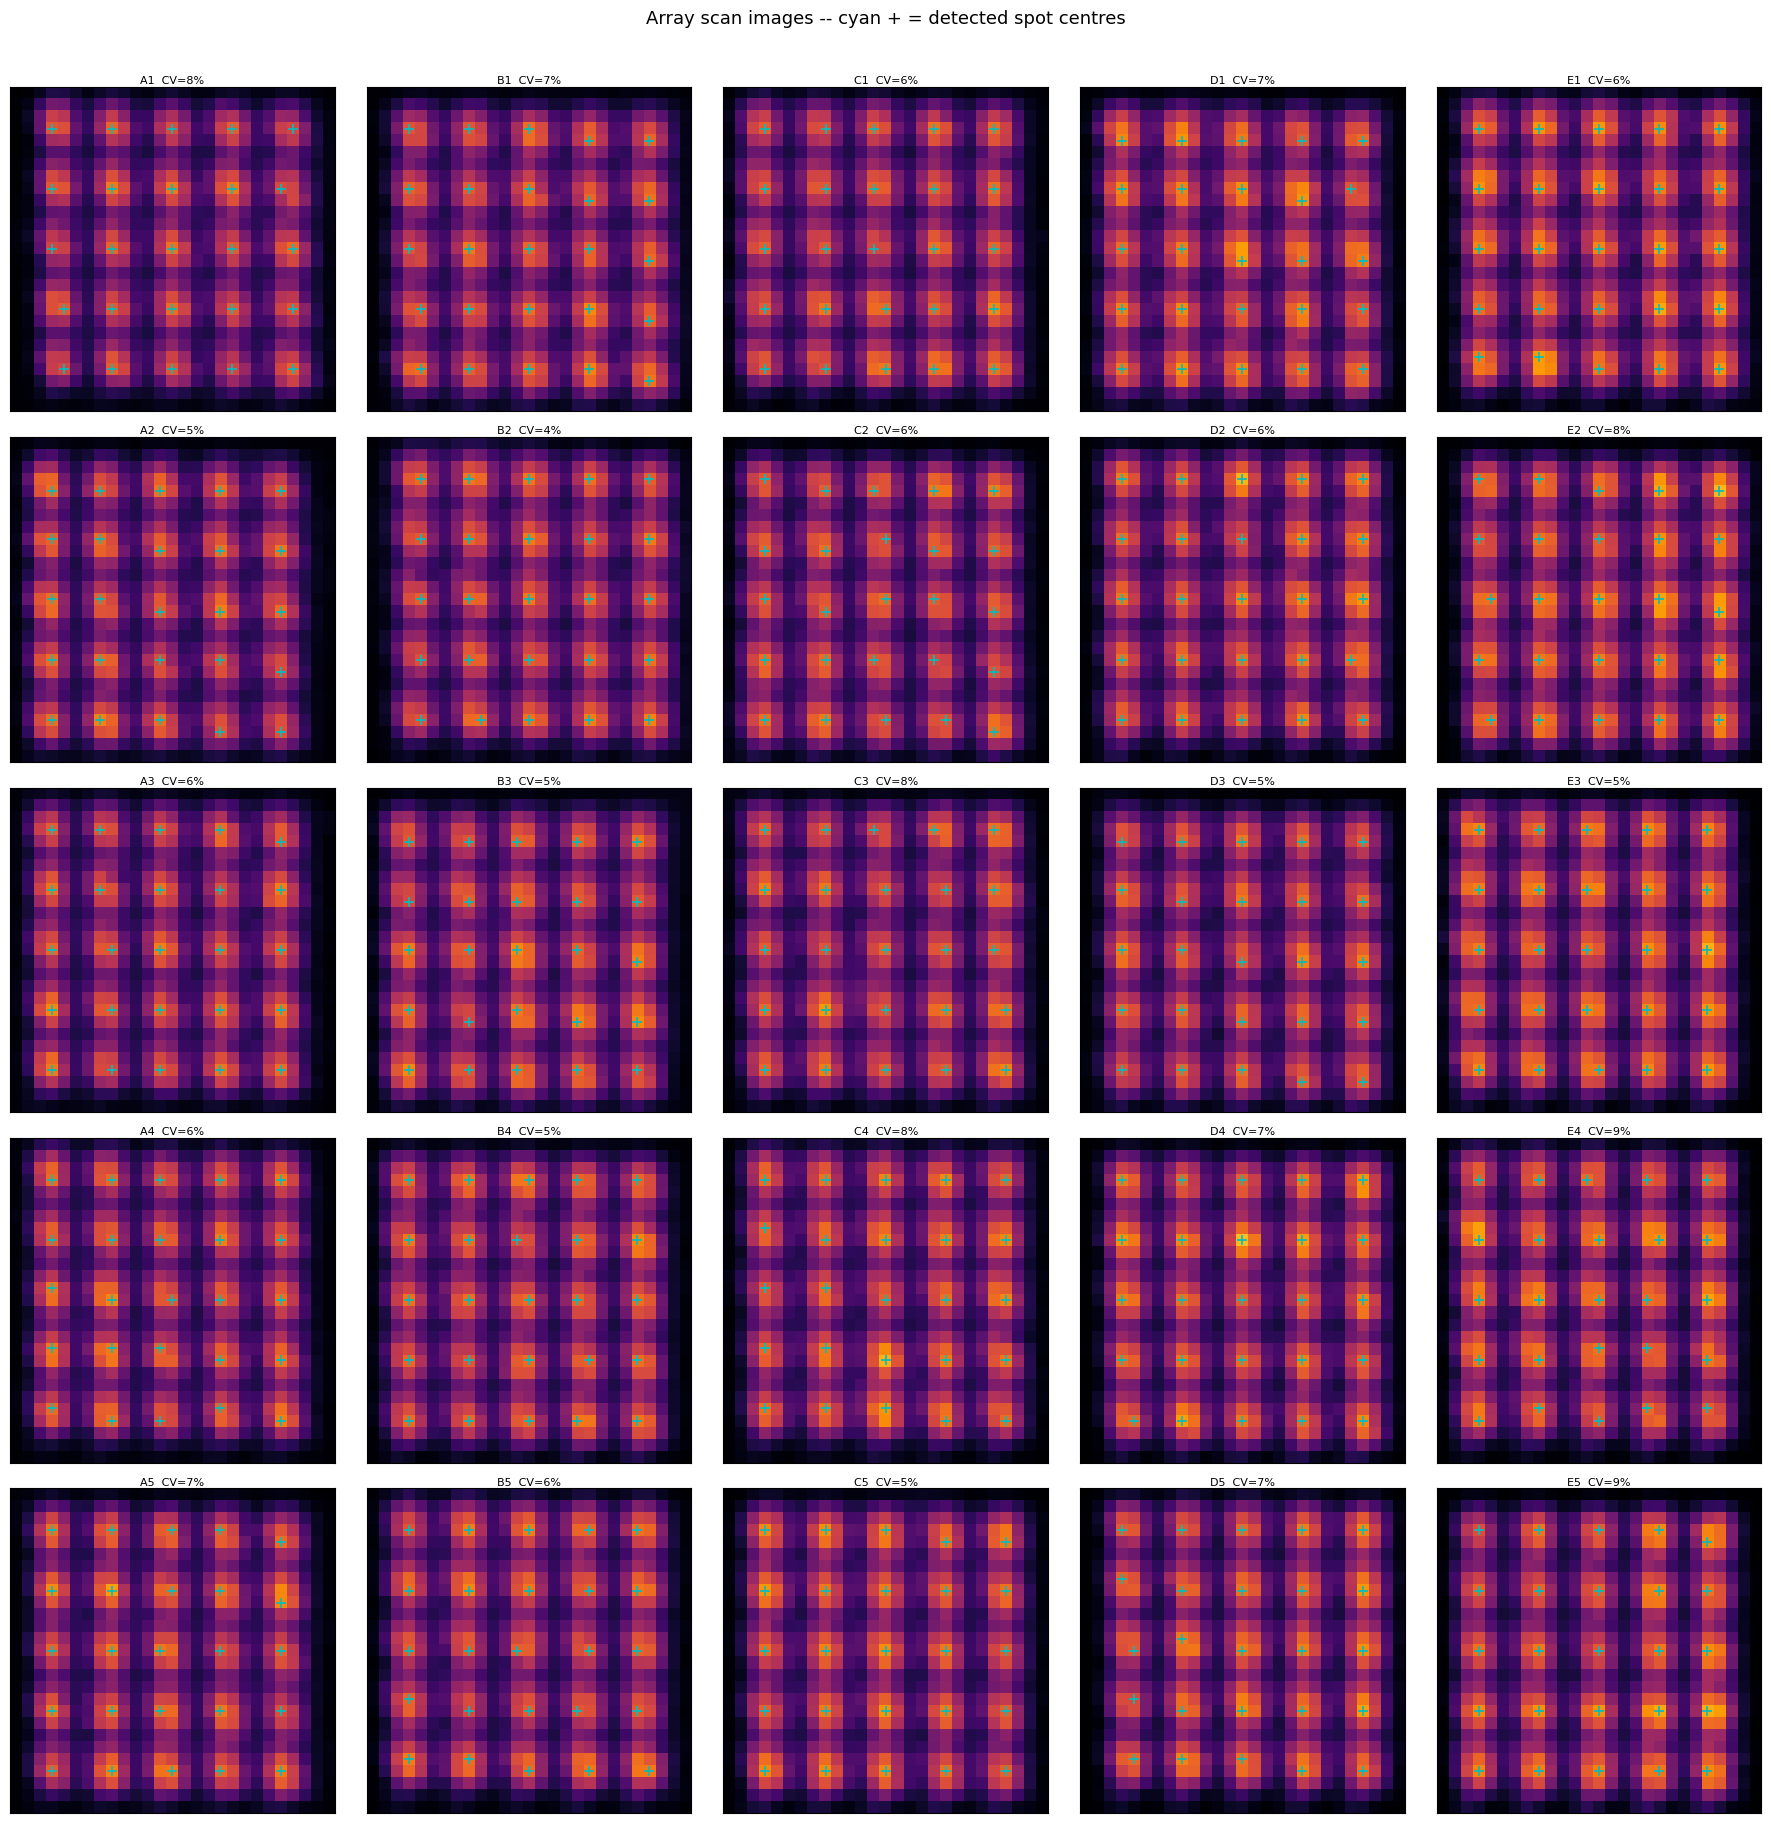

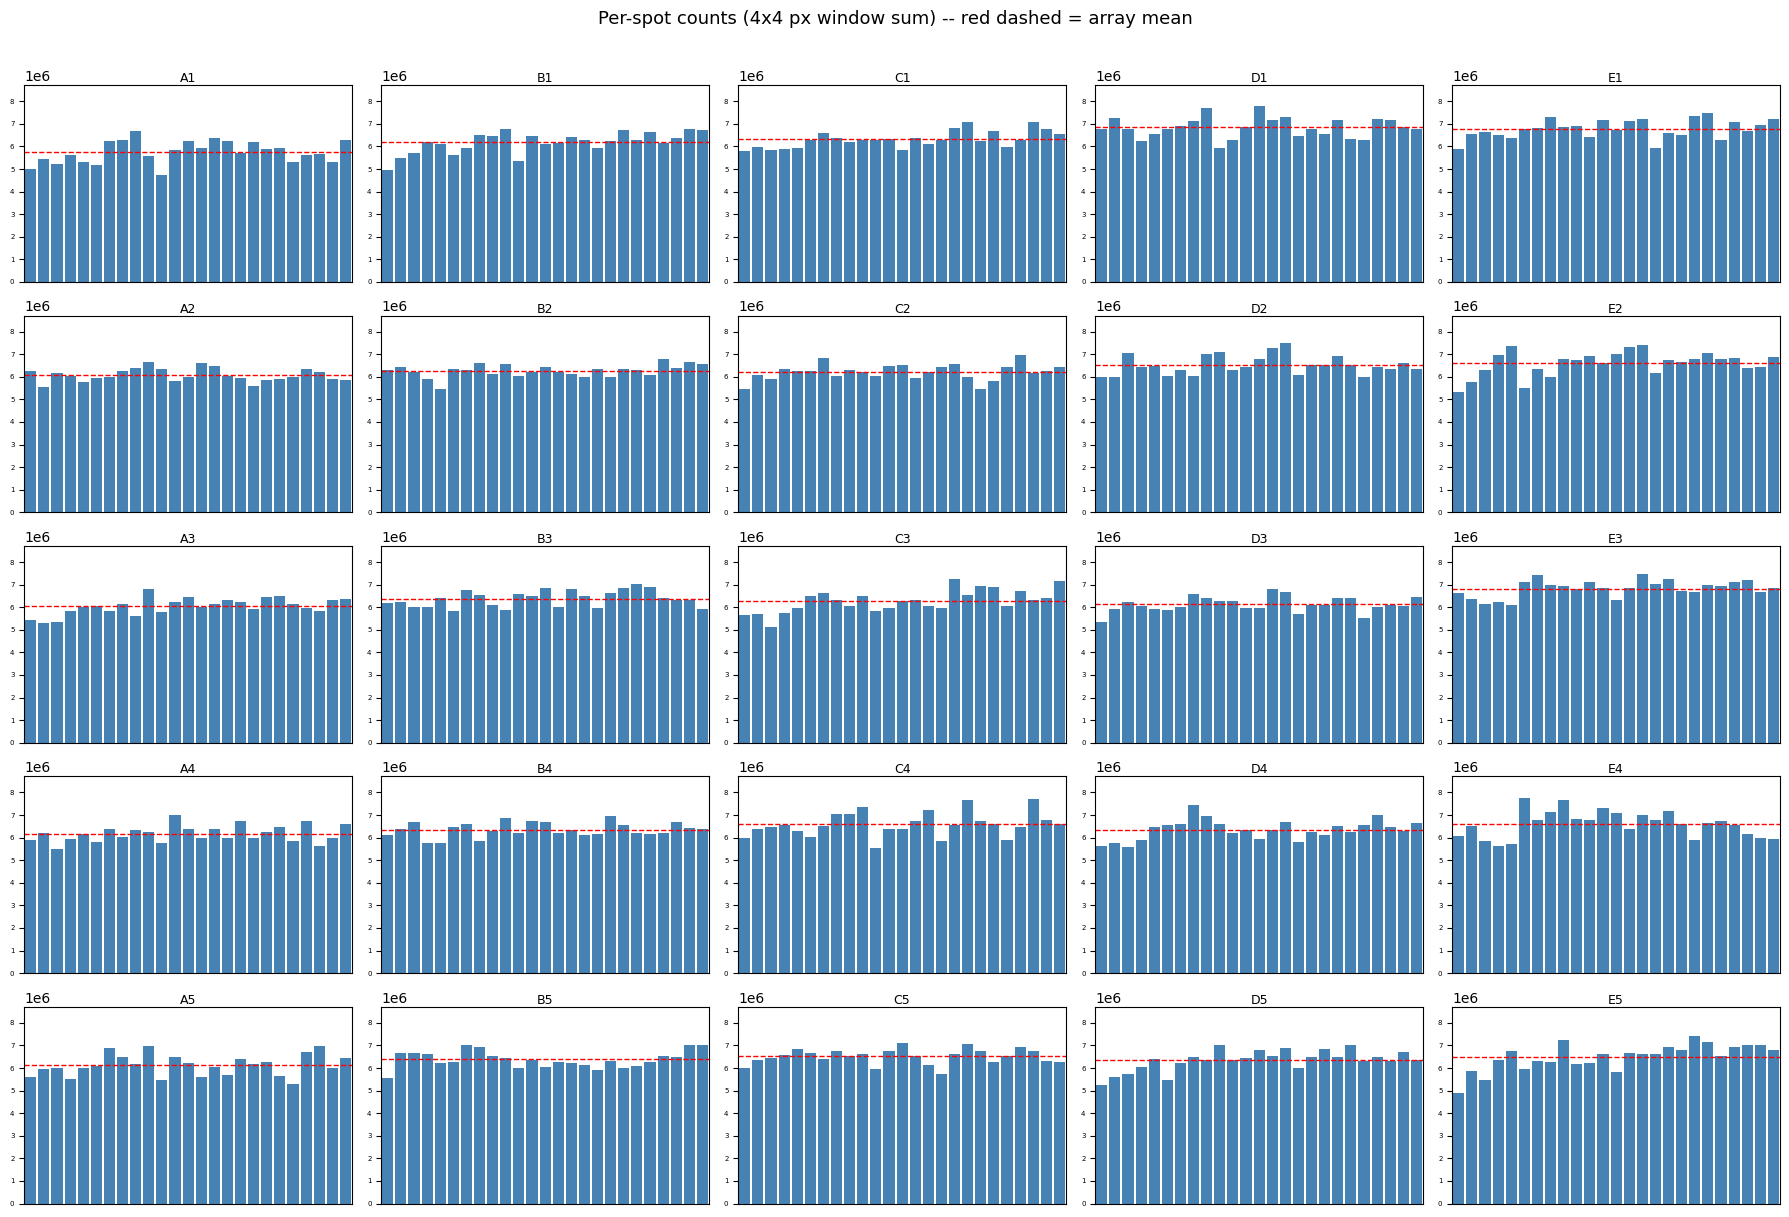

Most uniform array: B2
  CV   = 4.3%
  mean = 6270358 counts
  std  = 271376 counts


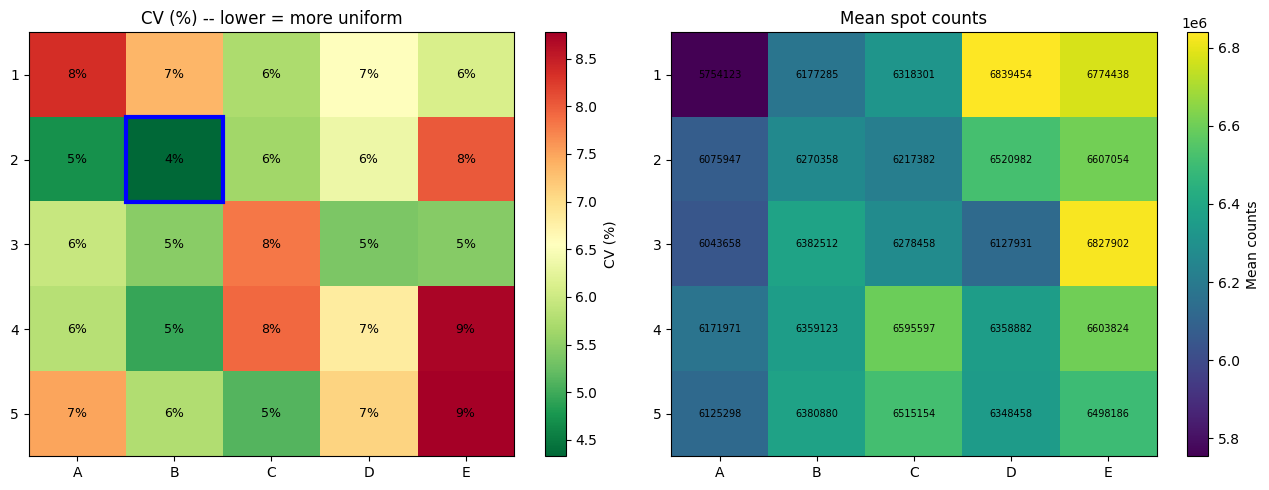

In [14]:
COL_LABELS = list('ABCDE')
ROW_LABELS = [str(i) for i in range(1, 6)]

HW = 13   # half-width for 25x25 px crop around each array centre

# -- Figure 1: Array scan images ----------------------------------------------
fig1, axes1 = plt.subplots(5, 5, figsize=(18, 18))
fig1.suptitle('Array scan images -- cyan + = detected spot centres', fontsize=13, y=1.01)

vlo = np.percentile(img, 10)
vhi = 1.0e6  # cap at 1.2 Mcps to avoid alignment-marker saturation

for ri in range(5):
    for ci in range(5):
        rc, cc = array_centers[(ri, ci)]
        r0 = max(0, rc - HW);  r1 = min(img.shape[0], rc + HW + 1)
        c0 = max(0, cc - HW);  c1 = min(img.shape[1], cc + HW + 1)
        ax = axes1[ri, ci]
        ax.imshow(img[r0:r1, c0:c1], cmap='inferno', origin='upper',
                  vmin=vlo, vmax=vhi)
        for pr, pc in results[(ri, ci)]['positions']:
            ax.plot(pc - c0, pr - r0, 'c+', markersize=7, markeredgewidth=1.2)
        label = f'{COL_LABELS[ci]}{ROW_LABELS[ri]}'
        cv = 100 * results[(ri, ci)]['cv']
        ax.set_title(f'{label}  CV={cv:.0f}%', fontsize=8, pad=2)
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('plots/NVarray_images.png', dpi=120, bbox_inches='tight')
plt.show()

# -- Figure 2: Per-spot count bar charts --------------------------------------
all_counts = np.concatenate([results[(ri, ci)]['counts']
                              for ri in range(5) for ci in range(5)])
ymax = all_counts.max() * 1.12

fig2, axes2 = plt.subplots(5, 5, figsize=(18, 12))
fig2.suptitle('Per-spot counts (4x4 px window sum) -- red dashed = array mean',
              fontsize=13, y=1.01)

for ri in range(5):
    for ci in range(5):
        counts = results[(ri, ci)]['counts']
        ax = axes2[ri, ci]
        ax.bar(range(1, 26), counts, color='steelblue', width=0.85)
        ax.axhline(counts.mean(), color='red', ls='--', lw=1)
        label = f'{COL_LABELS[ci]}{ROW_LABELS[ri]}'
        ax.set_title(label, fontsize=9, pad=2)
        ax.set_ylim(0, ymax)
        ax.set_xlim(0.5, 25.5)
        ax.set_xticks([]); ax.tick_params(axis='y', labelsize=5)

plt.tight_layout()
plt.savefig('plots/NVarray_spot_counts.png', dpi=120, bbox_inches='tight')
plt.show()

# -- Figure 3: CV heatmap + best array ----------------------------------------
cv_grid   = np.array([[results[(ri, ci)]['cv']   for ci in range(5)] for ri in range(5)])
mean_grid = np.array([[results[(ri, ci)]['mean'] for ci in range(5)] for ri in range(5)])
std_grid  = np.array([[results[(ri, ci)]['std']  for ci in range(5)] for ri in range(5)])

best_ri, best_ci = np.unravel_index(np.argmin(cv_grid), cv_grid.shape)
best_label = f'{COL_LABELS[best_ci]}{ROW_LABELS[best_ri]}'
print(f'Most uniform array: {best_label}')
print(f'  CV   = {100 * cv_grid[best_ri, best_ci]:.1f}%')
print(f'  mean = {mean_grid[best_ri, best_ci]:.0f} counts')
print(f'  std  = {std_grid[best_ri, best_ci]:.0f} counts')

fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes3[0].imshow(cv_grid * 100, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im0, ax=axes3[0], label='CV (%)')
axes3[0].set_xticks(range(5)); axes3[0].set_xticklabels(COL_LABELS)
axes3[0].set_yticks(range(5)); axes3[0].set_yticklabels(ROW_LABELS)
for ri in range(5):
    for ci in range(5):
        axes3[0].text(ci, ri, f'{100 * cv_grid[ri, ci]:.0f}%',
                      ha='center', va='center', fontsize=9)
axes3[0].add_patch(patches.Rectangle((best_ci - 0.5, best_ri - 0.5), 1, 1,
                   lw=3, edgecolor='blue', facecolor='none'))
axes3[0].set_title('CV (%) -- lower = more uniform')

im1 = axes3[1].imshow(mean_grid, cmap='viridis', aspect='auto')
plt.colorbar(im1, ax=axes3[1], label='Mean counts')
axes3[1].set_xticks(range(5)); axes3[1].set_xticklabels(COL_LABELS)
axes3[1].set_yticks(range(5)); axes3[1].set_yticklabels(ROW_LABELS)
for ri in range(5):
    for ci in range(5):
        axes3[1].text(ci, ri, f'{mean_grid[ri, ci]:.0f}',
                      ha='center', va='center', fontsize=7)
axes3[1].set_title('Mean spot counts')

plt.tight_layout()
plt.savefig('plots/NVarray_summary.png', dpi=120, bbox_inches='tight')
plt.show()


In [15]:
#TO DO: find 3X3 array with most uniform counts over column E (gradient max sensitivity)

Most uniform 3x3 sub-array (225 total):
  Array  : B2
  Window top-left (1-indexed): row=1, col=1
  Centre spot (1-indexed)    : row=2, col=2
  Centre pixel               : row=88, col=40
  CV=2.3%  mean=6326698  std=147050

Array    Best CV   Centre (r,c)    Centre px (r,c)
--------------------------------------------------
A1          4.7%  (3,3)          (63,16)
B1          3.4%  (3,4)          (63,50)
C1          3.5%  (2,4)          (59,79)
D1          4.7%  (4,3)          (69,104)
E1          3.8%  (2,3)          (60,133)
A2          3.6%  (3,2)          (92,11)
B2          2.3%  (2,2)          (88,40)
C2          3.1%  (2,4)          (89,79)
D2          3.6%  (4,2)          (99,99)
E2          3.7%  (4,2)          (99,128)
A3          3.5%  (3,2)          (122,12)
B3          3.9%  (4,2)          (128,41)
C3          4.7%  (3,4)          (123,80)
D3          3.6%  (4,2)          (128,99)
E3          4.1%  (4,2)          (129,129)
A4          2.8%  (3,4)          (152,21)
B4     

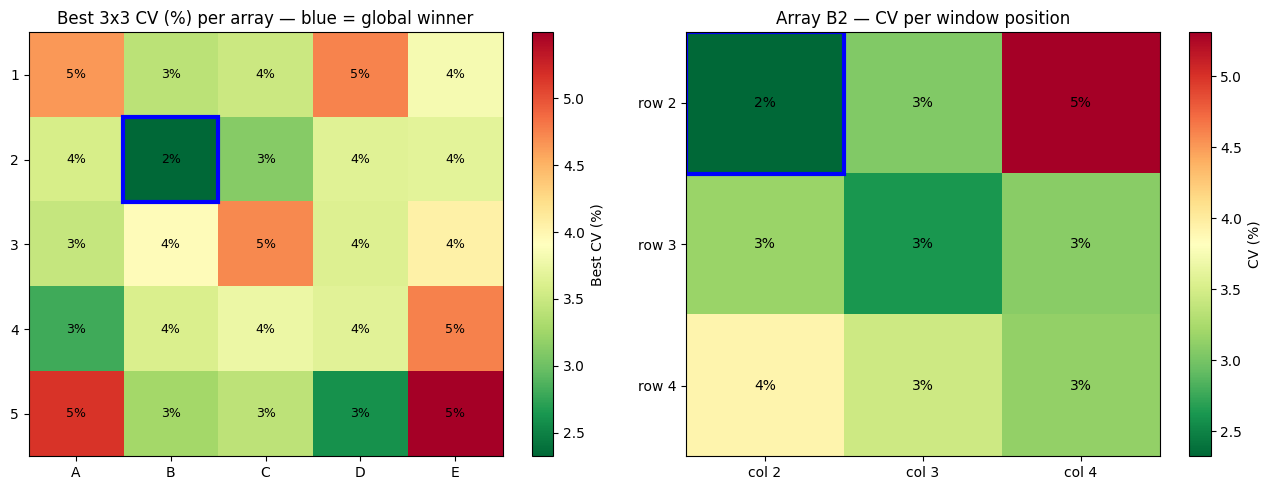

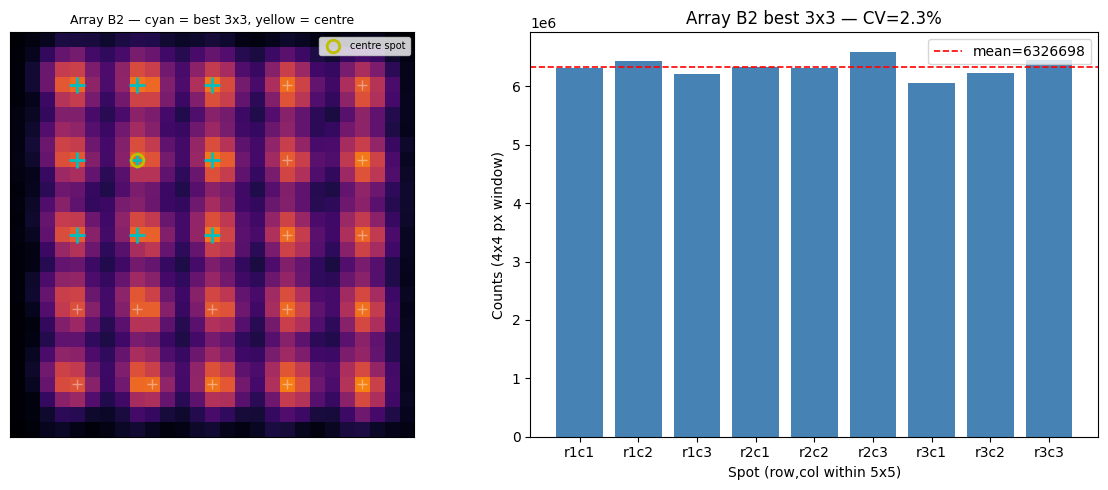

In [16]:
# -- Sliding 3x3 sub-array search: 9 positions x 25 arrays = 225 sub-arrays --
# Spots stored row-major; reshape to (5,5).
# Top-left corner of 3x3 window: r0,c0 in {0,1,2}.  Centre = (r0+1, c0+1).

sub = {}   # (ri, ci, r0, c0) -> dict

for ri in range(5):
    for ci in range(5):
        counts_2d = results[(ri, ci)]['counts'].reshape(5, 5)
        for r0 in range(3):
            for c0 in range(3):
                c9   = counts_2d[r0:r0+3, c0:c0+3].flatten()
                mean = float(c9.mean())
                std  = float(c9.std())
                sub[(ri, ci, r0, c0)] = {
                    'counts': c9,
                    'mean'  : mean,
                    'std'   : std,
                    'cv'    : std / mean,
                }

# -- Global best -----------------------------------------------------------
best_key = min(sub, key=lambda k: sub[k]['cv'])
bri, bci, br0, bc0 = best_key
best_label        = f'{COL_LABELS[bci]}{ROW_LABELS[bri]}'
centre_spot_flat  = (br0 + 1) * 5 + (bc0 + 1)
centre_r, centre_c = results[(bri, bci)]['positions'][centre_spot_flat]

print(f'Most uniform 3x3 sub-array (225 total):')
print(f'  Array  : {best_label}')
print(f'  Window top-left (1-indexed): row={br0+1}, col={bc0+1}')
print(f'  Centre spot (1-indexed)    : row={br0+2}, col={bc0+2}')
print(f'  Centre pixel               : row={centre_r}, col={centre_c}')
print(f'  CV={100*sub[best_key]["cv"]:.1f}%  mean={sub[best_key]["mean"]:.0f}  std={sub[best_key]["std"]:.0f}')

# -- Per-array table: best 3x3 window centre (1-indexed within 5x5) --------
print()
print(f'{"Array":<6}  {"Best CV":>8}  {"Centre (r,c)":>13}  {"Centre px (r,c)":>17}')
print('-' * 50)
for ri in range(5):
    for ci in range(5):
        best_r0, best_c0 = min(
            ((r0, c0) for r0 in range(3) for c0 in range(3)),
            key=lambda rc: sub[(ri, ci, rc[0], rc[1])]['cv']
        )
        cv_val   = sub[(ri, ci, best_r0, best_c0)]['cv']
        ctr_row  = best_r0 + 2      # 1-indexed centre row in 5x5
        ctr_col  = best_c0 + 2      # 1-indexed centre col in 5x5
        ctr_flat = (best_r0 + 1) * 5 + (best_c0 + 1)
        pr, pc   = results[(ri, ci)]['positions'][ctr_flat]
        label    = f'{COL_LABELS[ci]}{ROW_LABELS[ri]}'
        print(f'{label:<6}  {100*cv_val:>7.1f}%  ({ctr_row},{ctr_col}){" "*8}  ({pr},{pc})')

# -- Figure 1: per-array best-CV heatmap + winning-array window map ---------
best_cv_grid = np.array([
    [min(sub[(ri, ci, r0, c0)]['cv'] for r0 in range(3) for c0 in range(3))
     for ci in range(5)]
    for ri in range(5)
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(best_cv_grid * 100, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im0, ax=axes[0], label='Best CV (%)')
axes[0].set_xticks(range(5)); axes[0].set_xticklabels(COL_LABELS)
axes[0].set_yticks(range(5)); axes[0].set_yticklabels(ROW_LABELS)
for ri in range(5):
    for ci in range(5):
        axes[0].text(ci, ri, f'{100*best_cv_grid[ri,ci]:.0f}%',
                     ha='center', va='center', fontsize=9)
axes[0].add_patch(patches.Rectangle((bci - 0.5, bri - 0.5), 1, 1,
                  lw=3, edgecolor='blue', facecolor='none'))
axes[0].set_title('Best 3x3 CV (%) per array — blue = global winner')

cv_9 = np.array([[sub[(bri, bci, r0, c0)]['cv'] for c0 in range(3)] for r0 in range(3)])
im1 = axes[1].imshow(cv_9 * 100, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im1, ax=axes[1], label='CV (%)')
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(['col 2','col 3','col 4'])
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(['row 2','row 3','row 4'])
for r0 in range(3):
    for c0 in range(3):
        axes[1].text(c0, r0, f'{100*cv_9[r0,c0]:.0f}%',
                     ha='center', va='center', fontsize=10)
axes[1].add_patch(patches.Rectangle((bc0 - 0.5, br0 - 0.5), 1, 1,
                  lw=3, edgecolor='blue', facecolor='none'))
axes[1].set_title(f'Array {best_label} — CV per window position')

plt.tight_layout()
plt.savefig('plots/NVarray_3x3_sliding.png', dpi=120, bbox_inches='tight')
plt.show()

# -- Figure 2: winning array image with best 3x3 highlighted -----------------
rc, cc    = array_centers[(bri, bci)]
r0_px = max(0, rc - HW);  r1_px = min(img.shape[0], rc + HW + 1)
c0_px = max(0, cc - HW);  c1_px = min(img.shape[1], cc + HW + 1)

all_pos   = results[(bri, bci)]['positions']
inner_idx = [(br0 + dr) * 5 + (bc0 + dc) for dr in range(3) for dc in range(3)]
inner_pos = [all_pos[k] for k in inner_idx]
outer_pos = [all_pos[k] for k in range(25) if k not in inner_idx]

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

ax = axes2[0]
ax.imshow(img[r0_px:r1_px, c0_px:c1_px], cmap='inferno', origin='upper',
          vmin=vlo, vmax=vhi)
for pr, pc in outer_pos:
    ax.plot(pc - c0_px, pr - r0_px, 'w+', markersize=7, markeredgewidth=1, alpha=0.4)
for pr, pc in inner_pos:
    ax.plot(pc - c0_px, pr - r0_px, 'c+', markersize=11, markeredgewidth=2)
ax.plot(centre_c - c0_px, centre_r - r0_px, 'yo', markersize=9,
        markerfacecolor='none', markeredgewidth=2, label='centre spot')
ax.set_title(f'Array {best_label} — cyan = best 3x3, yellow = centre', fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(fontsize=7)

ax2 = axes2[1]
c9_counts = sub[best_key]['counts']
labels_9  = [f'r{br0+dr+1}c{bc0+dc+1}' for dr in range(3) for dc in range(3)]
ax2.bar(range(9), c9_counts, color='steelblue', width=0.8, tick_label=labels_9)
ax2.axhline(c9_counts.mean(), color='red', ls='--', lw=1.2,
            label=f'mean={c9_counts.mean():.0f}')
ax2.set_xlabel('Spot (row,col within 5x5)')
ax2.set_ylabel('Counts (4x4 px window)')
ax2.set_title(f'Array {best_label} best 3x3 — CV={100*sub[best_key]["cv"]:.1f}%')
ax2.legend()

plt.tight_layout()
plt.savefig('plots/NVarray_best_3x3_window.png', dpi=120, bbox_inches='tight')
plt.show()
